In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix


In [2]:
import glob
import os

base_dir = "/data1st1/junyi/correctdata/GSE133549/*/"
human_files = sorted(glob.glob(os.path.join(base_dir, "*human*exp_mat*.tsv.gz")))
print(f"Found {len(human_files)} human matrix file(s):")
for f in human_files:
    print(" -", os.path.basename(f))

file_path = human_files[0]

Found 14 human matrix file(s):
 - GSE133535_10X2x5Kcell250Kreads_human_exp_mat.tsv.gz
 - GSE133536_10X8x10Kcell25Kreads_human_exp_mat.tsv.gz
 - GSE133537_C1HTmedium_human_exp_mat.tsv.gz
 - GSE133538_C1HTsmall_human_exp_mat.tsv.gz
 - GSE133539_CELseq2_human_exp_mat.tsv.gz
 - GSE133540_Dropseq_human_exp_mat.tsv.gz
 - GSE133541_ICELL8_human_exp_mat.tsv.gz
 - GSE133542_MARSseq_human_exp_mat.tsv.gz
 - GSE133543_QUARTZseq_human_exp_mat.tsv.gz
 - GSE133544_SCRBseq_human_exp_mat.tsv.gz
 - GSE133545_SMARTseq2_human_exp_mat.tsv.gz
 - GSE133546_SingleNuclei_human_exp_mat.tsv.gz
 - GSE133547_ddSEQ_human_exp_mat.tsv.gz
 - GSE133548_inDrop_human_exp_mat.tsv.gz


In [3]:
# Load each human matrix, stamp its filename into obs, then concatenate
adatas = []
for fp in human_files:
    expr_matrix = pd.read_csv(fp, sep='\t', index_col=0, compression='gzip')
    mat_X = csr_matrix(np.round(expr_matrix.T.values).astype(int))

    ad = sc.AnnData(
        X=mat_X,
        obs=pd.DataFrame(index=expr_matrix.columns),
        var=pd.DataFrame(index=expr_matrix.index),
    )
    ad.obs["source_file"] = os.path.basename(fp)
    ad.var_names_make_unique()
    adatas.append(ad)

adata = sc.concat(adatas, join="outer", label="sample_id", keys=[os.path.basename(f) for f in human_files])

print(adata)
print(adata.obs.head())

AnnData object with n_obs × n_vars = 139617 × 47768
    obs: 'source_file', 'sample_id'
    layers: None (.X)
                                                                      source_file  \
10X2x5K_64220_AAACCTGAGACGCACA  GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...   
10X2x5K_64220_AAACCTGAGCCACCTG  GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...   
10X2x5K_64220_AAACCTGAGTGCGTGA  GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...   
10X2x5K_64220_AAACCTGCACTGTGTA  GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...   
10X2x5K_64220_AAACCTGCAGACTCGC  GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...   

                                                                        sample_id  
10X2x5K_64220_AAACCTGAGACGCACA  GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...  
10X2x5K_64220_AAACCTGAGCCACCTG  GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...  
10X2x5K_64220_AAACCTGAGTGCGTGA  GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...  
10X2x5K_64220_AAACCTGCACTGTGTA  GSE133535_1

In [1]:
adata.obs

NameError: name 'adata' is not defined

In [5]:
adata.write_h5ad("/data1st1/junyi/correctdata/GSE133549/human_exp_mat.h5ad")

In [2]:
import scanpy as sc
adata = sc.read_h5ad("/data1st1/junyi/correctdata/GSE133549/human_exp_mat.h5ad")

In [3]:
adata.obs

,source_file,sample_id
10X2x5K_64220_AAACCTGAGACGCACA,GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...,GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...
10X2x5K_64220_AAACCTGAGCCACCTG,GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...,GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...
10X2x5K_64220_AAACCTGAGTGCGTGA,GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...,GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...
10X2x5K_64220_AAACCTGCACTGTGTA,GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...,GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...
10X2x5K_64220_AAACCTGCAGACTCGC,GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...,GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...
...,...,...
1CB_S1_TTTGTGTCCTATAGAG,GSE133548_inDrop_human_exp_mat.tsv.gz,GSE133548_inDrop_human_exp_mat.tsv.gz
1CB_S1_TTTGTGTCCTTCAGGT,GSE133548_inDrop_human_exp_mat.tsv.gz,GSE133548_inDrop_human_exp_mat.tsv.gz
1CB_S1_TTTGTGTCGCTTCAAT,GSE133548_inDrop_human_exp_mat.tsv.gz,GSE133548_inDrop_human_exp_mat.tsv.gz
1CB_S1_TTTGTGTCTCCAGTCC,GSE133548_inDrop_human_exp_mat.tsv.gz,GSE133548_inDrop_human_exp_mat.tsv.gz


In [4]:
folder = "/data1st1/junyi/correctdata/GSE118767/RAW/"

In [16]:
import glob
import os
import pandas as pd
import numpy as np

In [17]:
# ==== GSE118767: 把所有细胞的 metadata 读进一个 AnnData ====
# 只读每个 count 矩阵的表头（第一列是基因列，其余列 = 细胞）+ 元数据文件，不读表达矩阵
import re

count_files = sorted(glob.glob(os.path.join(folder, "*counts.csv")) +
                     glob.glob(os.path.join(folder, "*gene_count*.csv")))
print(f"找到 {len(count_files)} 个 count 矩阵")

def parse_protocol(fname):
    """从文件名推断协议/样本名：GSMxxxx_POP_counts.csv -> POP"""
    f = os.path.basename(fname)
    f = re.sub(r"^GSM\d+_", "", f)
    f = f.replace("_counts.csv", "")
    f = f.replace("_gene_count", "")        # dropseq_gene_count.csv -> dropseq
    f = f.replace(".csv", "")
    return "10x" if f == "gene_count" else f  # GSM3618014 无协议后缀 -> 10x Chromium

# 1) 每个矩阵的列名 = 一批细胞，只读表头
all_obs = []
for fp in count_files:
    hdr = pd.read_csv(fp, nrows=0)
    cells = hdr.columns[1:]                      # 第一列是基因列，其余是细胞
    obs_i = pd.DataFrame({"sample": os.path.basename(fp),
                          "protocol": parse_protocol(fp)},
                         index=cells)
    obs_i.index.name = "cell"
    all_obs.append(obs_i)
obs = pd.concat(all_obs)
print("总细胞数:", len(obs))
print(obs.groupby("protocol").size())

# 2) NN84 (CelSeq2_SC): 合并 GEO metadata 模板（按 Sample name = 列名 join）
meta_path = os.path.join(folder, "GSM3336845_metadata_and_cellular_barcodes.txt")
raw_meta = pd.read_csv(meta_path, sep='\t', comment='#', header=None, encoding='latin-1')
hdr_idx = raw_meta.index[raw_meta[0] == "Sample name"][0]
meta = raw_meta.iloc[hdr_idx + 1:].copy()
meta.columns = raw_meta.iloc[hdr_idx].astype(str).str.strip().tolist()
meta = meta[meta["Sample name"].notna()].set_index("Sample name")
keep = ["title", "source name", "organism", "characteristics: cellular barcode"]
meta = meta[keep].rename(columns={"characteristics: cellular barcode": "barcode"})
obs = obs.join(meta, how="left")
# 模板里的 A1.. 是 NN84 专属；CelSeq2_Mixture/SortSeq/RPI 等板式协议列名也是 A1..，
# 直接按细胞名 join 会给他们错误贴上 NN84 的 metadata —— 只保留 NN84 文件的匹配
obs.loc[obs["sample"] != "GSM3336845_NN84_Celseq2_SC_counts.csv", list(meta.columns)] = np.nan
print("NN84 匹配到 metadata 的细胞数:", obs["barcode"].notna().sum())

# 3) dropseq: 合并 index_anno（CELL_xxx -> 条形码 + 读数）
ia = pd.read_csv(os.path.join(folder, "GSM3336849_index_anno.csv"), header=None,
                 names=["cell", "barcode_dropseq", "n_reads"]).set_index("cell")
ia = ia.rename(columns={"n_reads": "n_reads_dropseq"})
obs = obs.join(ia, how="left")
print("dropseq 匹配到 index_anno 的细胞数:", obs["n_reads_dropseq"].notna().sum())

# 4) 汇总成 AnnData（只含 metadata，X=None）；跨样本条形码可能重名 -> 拼接索引
obs.index = obs["sample"] + "_" + obs.index
adata_meta = sc.AnnData(obs=obs)
print("adata:", adata_meta.n_obs, "cells")
adata_meta.obs.head()

找到 13 个 count 矩阵
总细胞数: 12711
protocol
10x                       5001
CelSeq2_Mixture_Sample     383
NN84_Celseq2_SC            383
POP                         24
SC1                        347
SC2                        347
SC3                        347
SC4                        347
SortSeq_Mixture_Sample     383
dropseq                   4000
gene_count_RPI4            383
gene_count_RPI5            383
gene_count_RPI6            383
dtype: int64
NN84 匹配到 metadata 的细胞数: 383
dropseq 匹配到 index_anno 的细胞数: 4000
adata: 12711 cells


,sample,protocol,title,source name,organism,barcode,barcode_dropseq,n_reads_dropseq
GSM3295023_POP_counts.csv_POP_O1,GSM3295023_POP_counts.csv,POP,NaN,NaN,NaN,NaN,NaN,NaN
GSM3295023_POP_counts.csv_POP_O2,GSM3295023_POP_counts.csv,POP,NaN,NaN,NaN,NaN,NaN,NaN
GSM3295023_POP_counts.csv_POP_O3,GSM3295023_POP_counts.csv,POP,NaN,NaN,NaN,NaN,NaN,NaN
GSM3295023_POP_counts.csv_POP_O4,GSM3295023_POP_counts.csv,POP,NaN,NaN,NaN,NaN,NaN,NaN
GSM3295023_POP_counts.csv_POP_O5,GSM3295023_POP_counts.csv,POP,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
df_r

,unaligned,aligned_unmapped,mapped_to_exon,mapped_to_intron,ambiguous_mapping,mapped_to_ERCC,mapped_to_MT,number_of_genes,total_count_per_cell,non_mt_percent,non_ribo_percent,outliers,cell_line,cell_line_demuxlet,demuxlet_cls
CELL_000001,167234,8341,526950,40991,21392,0,22342,11237,266880,0.823985,0.797096,False,HCC827,HCC827,SNG
CELL_000002,171821,10047,513676,41809,23139,0,15065,11759,249152,0.823525,0.787884,False,H1975,HCC827,DBL
CELL_000003,174510,8608,513021,42270,20170,0,20943,11203,251204,0.828956,0.801715,False,HCC827,HCC827,SNG
CELL_000004,158346,7796,504676,39684,18628,0,14021,11237,250040,0.839618,0.816149,False,HCC827,HCC827,SNG
CELL_000005,159070,6968,486645,38252,20029,0,14100,10920,244441,0.838746,0.798577,False,HCC827,HCC827,SNG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CELL_000939,35877,2227,115822,8543,5184,0,4061,8240,84182,0.809377,0.811824,False,H1975,H1975,SNG
CELL_000943,37475,2229,105134,13754,4567,0,5626,7334,58540,0.846379,0.773164,False,H1975,H1975,SNG
CELL_000946,35066,2039,105214,14480,3462,0,4050,7315,51903,0.831185,0.834846,False,H2228,H2228,SNG
CELL_000955,33183,3061,84351,19273,3319,0,4322,6809,42862,0.837128,0.796160,False,HCC827,HCC827,SNG


In [ ]:
# ==== 把 CellBench_metadata 里的全部 metadata 导入 pandas（GSE118767 的 ground truth 标签）====
meta_dir = "/data1st1/junyi/correctdata/GSE118767/CellBench_metadata/"

# 1) 读入全部 14 个 metadata 文件，行名 = 细胞/孔位，加 dataset 列标注来源
meta_files = sorted(glob.glob(os.path.join(meta_dir, "*.metadata.csv.gz")))
print(f"找到 {len(meta_files)} 个 metadata 文件")

frames = []
for fp in meta_files:
    dataset = os.path.basename(fp).replace(".metadata.csv.gz", "")
    df = pd.read_csv(fp, index_col=0)
    df.index.name = "cell"
    df["dataset"] = dataset
    frames.append(df)
meta_all = pd.concat(frames)
print("合并后形状:", meta_all.shape)

# 2) 修正 CellBench 的数据 bug：5cl 板的 p2/p3 行名被误标成 p1_ 前缀 -> 统一剥掉 p1_
mask5cl = meta_all["dataset"].str.startswith("sc_celseq2_5cl")
meta_all.index = [i[3:] if (m and i.startswith("p1_")) else i
                  for m, i in zip(mask5cl, meta_all.index)]

# 3) 只保留标签列（去掉 unaligned/mapped_* 等纯 QC 统计列），方便使用
LABEL_COLS = ["H1975", "H2228", "HCC827", "traj", "poor_quality",          # cellmix: 每孔各细胞系细胞数
              "H2228_prop", "H1975_prop", "HCC827_prop", "mRNA_amount", "mix",  # RNAmix: RNA 混合比例
              "cell_line", "cell_line_demuxlet", "demuxlet_cls"]           # 单细胞: 每细胞细胞系身份
labels = meta_all[LABEL_COLS + ["dataset"]].copy()
print()
print("=== 每个数据集的标签覆盖（非空行数）===")
print(labels.groupby("dataset")[LABEL_COLS].apply(lambda s: s.notna().sum()).to_string())
print()
print("=== 抽查 ===")
labels[labels["dataset"] == "cellmix1"].head(3)

In [26]:
adata.obs.protocol.value_counts()

protocol
10x                       5001
dropseq                   4000
CelSeq2_Mixture_Sample     383
SortSeq_Mixture_Sample     383
NN84_Celseq2_SC            383
gene_count_RPI4            383
gene_count_RPI5            383
gene_count_RPI6            383
SC1                        347
SC2                        347
SC3                        347
SC4                        347
POP                         24
Name: count, dtype: int64

In [27]:
adata.write_h5ad("/data1st1/junyi/correctdata/GSE118767/combined_mix.h5ad")

In [13]:
adata.write_h5ad("/data1st1/junyi/correctdata/GSE118767/all.h5ad")

In [2]:
adata_scvi = sc.read_h5ad("/data3/junyi/scvi/TH_scVImodel.h5ad")

In [3]:
hkg_priority = [
    "Aars", "Sars", "Polr2a", "Polr2f", "Psmd6", "Psmd7", "Psma5",
    "Rer1", "Ipo8", "Pop4", "Pes1", "Oaz1", "Rpl13a", "Rpl27",
    "Rps13", "Rps20", "Hprt1", "Gusb", "Ppia", "Ywhaz", "Cyc1",
    "Sdha", "Ubc",
]

# Keep only housekeeping genes available in this AnnData object and preserve
# the curated order so both methods use exactly the same y-axis genes.
hkg_genes = []
seen_genes = set()
for gene in hkg_priority:
    if gene in adata_scvi.var_names and gene not in seen_genes:
        hkg_genes.append(gene)
        seen_genes.add(gene)


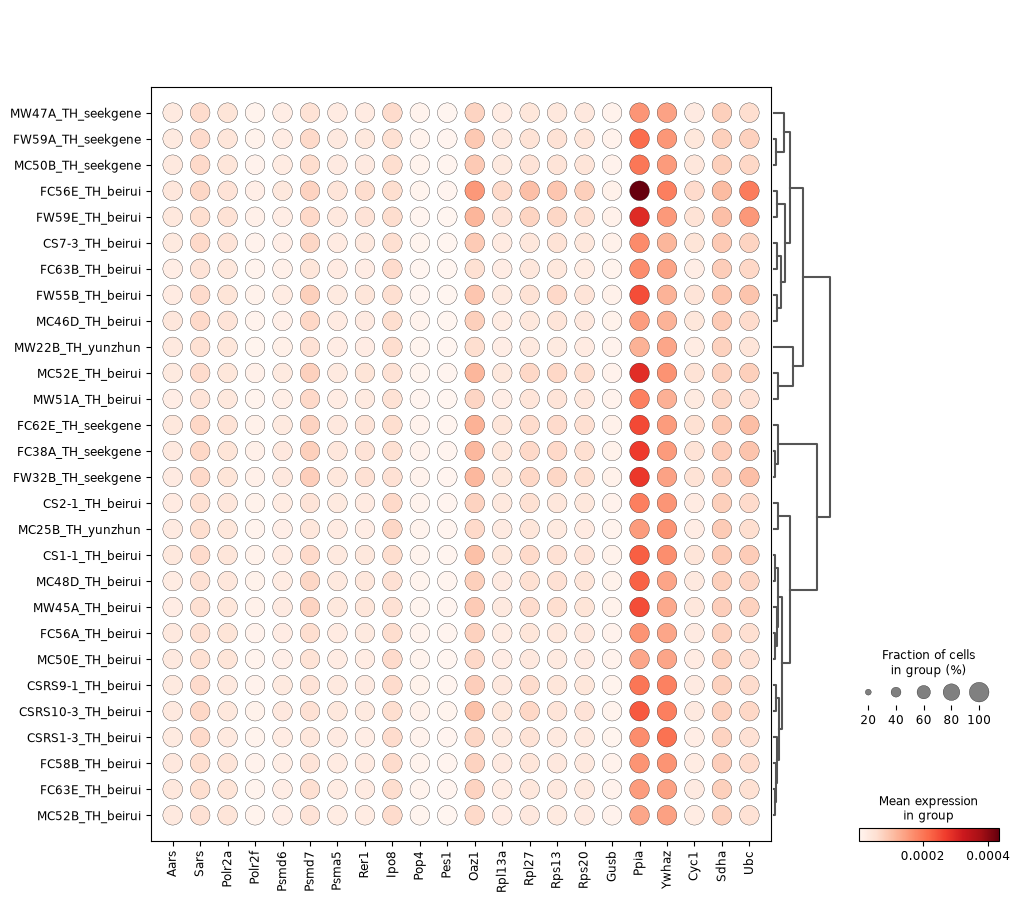

In [9]:
sc.pl.dotplot(
    adata_scvi,
    var_names=hkg_genes,
    groupby="sample",
    layer="scvi_nrom_counts",
    swap_axes=False,
    dendrogram=True,
    vmax=None,
    show=True,
)
